# Predicting Financial Stress Events using 20-day Rolling Volatility as a Stress Proxy.

In [ ]:
SEED = 45
# --- ENV FIRST ---
import os
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
# --- IMPORTS ---
import random
import numpy as np
import tensorflow as tf
# --- TF CONFIG ---
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.set_visible_devices([], 'GPU')
# --- SEEDS ---
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
# --- RESET ---
tf.keras.backend.clear_session()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score, roc_curve
import itertools
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
try:
  import keras_tuner as kt
except:
  !pip install keras-tuner
  import keras_tuner as kt
from google.colab import files
from google.colab import drive
import pandas as pd
import io
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.8 MB/s eta 0:00:00


In [ ]:
def import_data(file_path):
  try:
    drive.mount('/content/drive', force_remount=True)
    # Check if file exists
    if os.path.exists(file_path):
      df = pd.read_parquet(file_path)
      print(f"Loaded dataframe from Drive ({file_path})")
    else:
      raise FileNotFoundError(f"File not found at {file_path}")

  except Exception as e:
    print(f"Drive not available or file missing: {e}")
    print("Please upload dataframe manually.")
    uploaded = files.upload()

    # Automatically read the uploaded file
    file_name = list(uploaded.keys())[0]  # pick the first uploaded file
    try:
      df = pd.read_parquet(io.BytesIO(uploaded[file_name]))
    except:
      print("Wrong file extension. Parquet file required.")
    print(f"Loaded {file_name} from manual upload.")
    return df

In [ ]:
file_path = "..."
df_model_2 = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_model_2.parquet to df_model_2.parquet
Loaded df_model_2.parquet from manual upload.


In [ ]:
# split data in training and test set and apply purging
split_date = "2024-03-31"
purge = 20
train_2 = df_model_2.loc[:split_date].iloc[:-purge]
test_2  = df_model_2[df_model_2.index > split_date]
X_train_2 = train_2[["vn_volatility"]]
y_train_2 = train_2["systemic_stress_event"]
X_test_2  = test_2[["vn_volatility"]]
y_test_2  = test_2["systemic_stress_event"]

In [ ]:
def train_classifier(model, X_train, y_train, X_test, y_test, X_val=False, y_val=False, threshold=0.5, early_stopping=False):
  is_keras = hasattr(model, "fit") and hasattr(model, "predict") and not hasattr(model, "predict_proba")
  if is_keras:
    if early_stopping:
      model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, class_weight=class_weight, validation_data=(X_val, y_val), shuffle=False, callbacks=[combined_metric, es])
    else:
      model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, class_weight=class_weight, validation_data=(X_val, y_val), shuffle=False)
    y_score = model.predict(X_test).ravel()
    y_pred = (y_score >= threshold).astype(int)
  else:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

  # Output Following Metrics:
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_score)
  cm = confusion_matrix(y_test, y_pred)

  return recall, f1, roc_auc, cm, y_score, y_pred

In [ ]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes)#, rotation=45)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

## 5.1. Logistic Regression.

In [ ]:
lr_model_2 = LogisticRegression(class_weight="balanced")
lr_results_2 = train_classifier(lr_model_2, X_train_2, y_train_2, X_test_2, y_test_2)

In [ ]:
lr_recall_2, lr_f1_2, lr_roc_auc_2, lr_cm_2, lr_probs_2, lr_preds_2 = lr_results_2

Confusion matrix, without normalization
[[475   0]
 [ 25   0]]


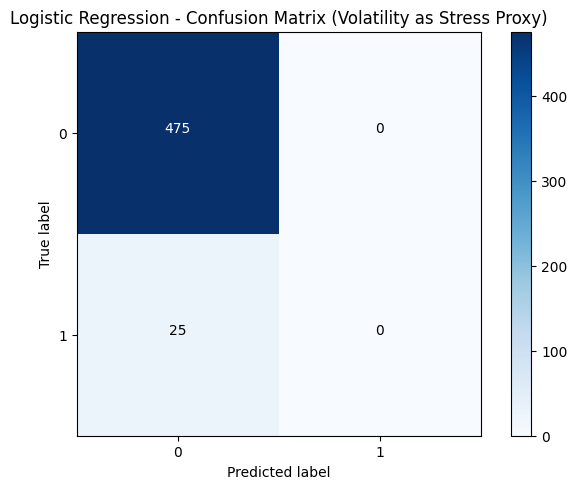

In [ ]:
plot_confusion_matrix(cm=lr_cm_2, classes=[0,1], normalize= False,  title='Logistic Regression - Confusion Matrix (Volatility as Stress Proxy)')

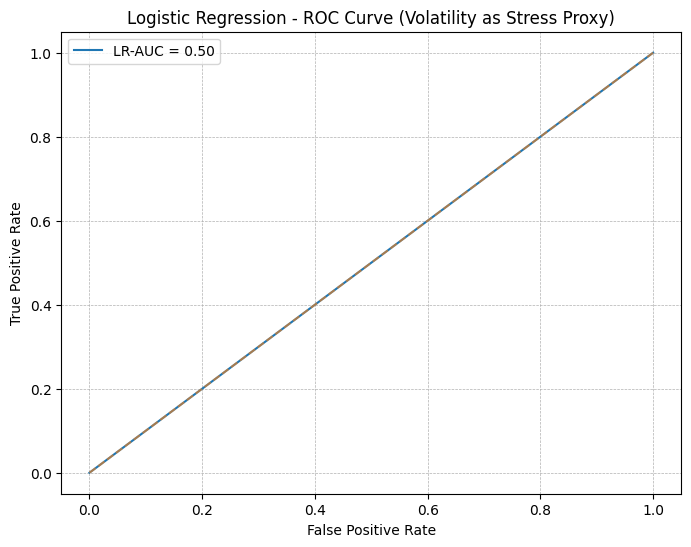

In [ ]:
fpr, tpr, thr = roc_curve(y_test_2, lr_probs_2)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LR-AUC = {lr_roc_auc_2:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve (Volatility as Stress Proxy)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
lr_results_2 = {'Recall': lr_recall_2, 'F1-Score': lr_f1_2, 'ROC-AUC': lr_roc_auc_2}
lr_results_2 = pd.DataFrame(lr_results_2, index=['Logistic Regression (Volatility as Stress Proxy)'])

In [ ]:
lr_results_2

,Recall,F1-Score,ROC-AUC
Logistic Regression (Volatility as Stress Proxy),0.0,0.0,0.5


## 5.2. Support Vector Machines.

In [ ]:
svm_model_2 = SVC(C=1.0, kernel='rbf', probability=True, class_weight="balanced")
svm_results_2 = train_classifier(svm_model_2, X_train_2, y_train_2, X_test_2, y_test_2)

In [ ]:
svm_recall_2, svm_f1_2, svm_roc_auc_2, svm_cm_2, svm_probs_2, svm_preds_2 = svm_results_2

Confusion matrix, without normalization
[[377  98]
 [ 15  10]]


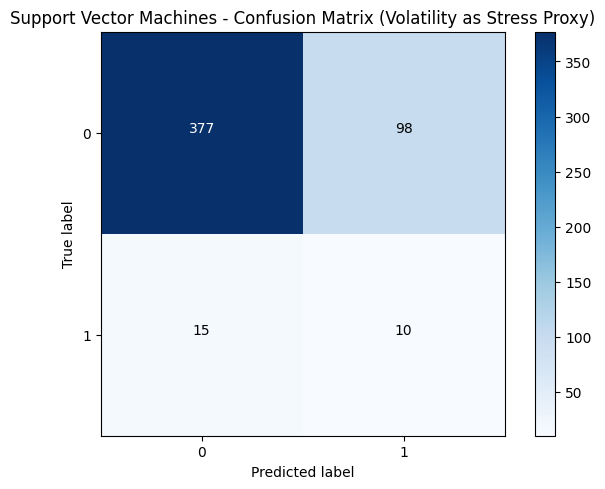

In [ ]:
plot_confusion_matrix(cm=svm_cm_2, classes=[0,1], normalize= False,  title='Support Vector Machines - Confusion Matrix (Volatility as Stress Proxy)')

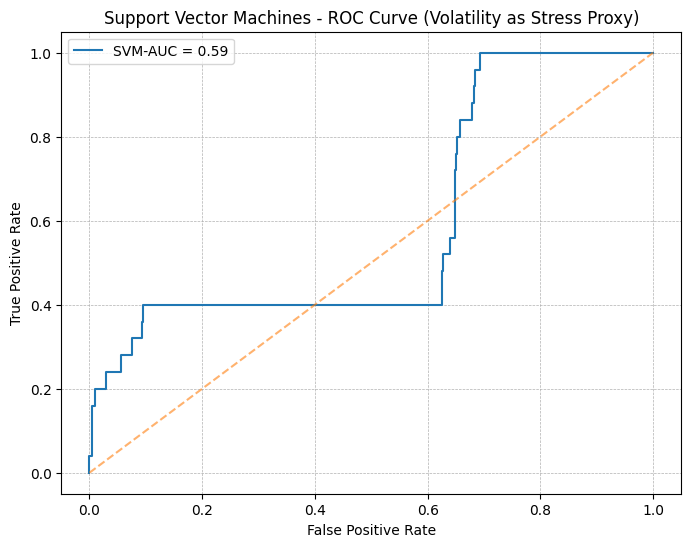

In [ ]:
fpr, tpr, thr = roc_curve(y_test_2, svm_probs_2)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM-AUC = {svm_roc_auc_2:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Machines - ROC Curve (Volatility as Stress Proxy)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
svm_results_2 = pd.DataFrame({'Recall': svm_recall_2, 'F1-Score': svm_f1_2, 'ROC-AUC': svm_roc_auc_2},index=['Support Vector Machines (Volatility as Stress Proxy)'])
svm_results_2

,Recall,F1-Score,ROC-AUC
Support Vector Machines (Volatility as Stress Proxy),0.4,0.150376,0.592758


## 5.3. Long Short-Term Memory (LSTM) Networks.

In [ ]:
timesteps = 60
split_idx = pd.Timestamp("2023-03-01")
X_train_lstm_bench_2 = X_train_2[X_train_2.index < split_idx].iloc[:-purge]
y_train_lstm_bench_2 = y_train_2[y_train_2.index < split_idx].iloc[:-purge]
X_val_lstm_bench_2 = X_train_2.loc[split_idx:]
y_val_lstm_bench_2 = y_train_2.loc[split_idx:]

X_train_values_bench_2 = X_train_lstm_bench_2.values
y_train_values_bench_2 = y_train_lstm_bench_2.values
X_test_values_bench_2 = X_test_2.values
y_test_values_bench_2 = y_test_2.values
X_val_values_bench_2 = X_val_lstm_bench_2.values
y_val_values_bench_2 = y_val_lstm_bench_2.values
X_train_seq_bench_2 = []
y_train_seq_bench_2 = []
X_test_seq_bench_2 = []
y_test_seq_bench_2 = []
X_val_seq_bench_2 = []
y_val_seq_bench_2 = []
for i in range(timesteps, len(X_train_values_bench_2)):
  X_train_seq_bench_2.append(X_train_values_bench_2[i - timesteps:i])
  y_train_seq_bench_2.append(y_train_values_bench_2[i])
for i in range(timesteps, len(X_test_values_bench_2)):
  X_test_seq_bench_2.append(X_test_values_bench_2[i - timesteps:i])
  y_test_seq_bench_2.append(y_test_values_bench_2[i])
for i in range(timesteps, len(X_val_values_bench_2)):
  X_val_seq_bench_2.append(X_val_values_bench_2[i - timesteps:i])
  y_val_seq_bench_2.append(y_val_values_bench_2[i])

X_train_seq_bench_2 = np.array(X_train_seq_bench_2)
y_train_seq_bench_2 = np.array(y_train_seq_bench_2)
X_test_seq_bench_2 = np.array(X_test_seq_bench_2)
y_test_seq_bench_2 = np.array(y_test_seq_bench_2)
X_val_seq_bench_2 = np.array(X_val_seq_bench_2)
y_val_seq_bench_2 = np.array(y_val_seq_bench_2)

In [ ]:
tf.keras.backend.clear_session()
input_shape = X_train_seq_bench_2.shape[1:]  # (60, num_features)
lstm_model_bench_2 = keras.Sequential()
lstm_model_bench_2.add(layers.LSTM(32, return_sequences=True, input_shape=input_shape))
lstm_model_bench_2.add(layers.Dropout(0.2))
lstm_model_bench_2.add(layers.LSTM(64, return_sequences=True))
lstm_model_bench_2.add(layers.Dropout(0.2))
lstm_model_bench_2.add(layers.LSTM(8, return_sequences=True))
lstm_model_bench_2.add(layers.Dropout(0.3))
lstm_model_bench_2.add(layers.LSTM(8, return_sequences=True))
lstm_model_bench_2.add(layers.Dropout(0.3))
lstm_model_bench_2.add(layers.LSTM(64, return_sequences=False))
lstm_model_bench_2.add(layers.Dropout(0.3))
# Dense layers
lstm_model_bench_2.add(layers.Dense(16, activation="relu"))
lstm_model_bench_2.add(layers.Dense(1, activation="sigmoid"))
# Compile
lstm_model_bench_2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")])

lstm_model_bench_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 8)          │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,809 (202.38 KB)

 Trainable params: 51,809 (202.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class CombinedMetric(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    logs = logs or {}
    recall = logs.get("val_recall", 0)
    pr_auc = logs.get("val_pr_auc", 0)
    logs["val_combined"] = 0.7 * recall + 0.3 * pr_auc

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
combined_metric = CombinedMetric()
es = tf.keras.callbacks.EarlyStopping(monitor="val_combined", mode="max", patience=75, restore_best_weights=True, verbose=1)
classes = np.unique(y_train_seq_bench_2)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_seq_bench_2)
class_weight = dict(zip(classes, weights))
epochs=200
batch_size=32

lstm_results_bench_2 = train_classifier(lstm_model_bench_2, X_train_seq_bench_2, y_train_seq_bench_2, X_test_seq_bench_2, y_test_seq_bench_2, X_val=X_val_seq_bench_2, y_val=y_val_seq_bench_2, early_stopping=True)

Epoch 1/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - loss: 0.6989 - pr_auc: 0.0504 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.6785 - val_pr_auc: 0.0495 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_combined: 0.0149
Epoch 2/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.6946 - pr_auc: 0.0522 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.6807 - val_pr_auc: 0.0495 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_combined: 0.0149
Epoch 3/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - loss: 0.6945 - pr_auc: 0.0531 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.6827 - val_pr_auc: 0.0495 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_combined: 0.0149
Epoch 4/200
81/81 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 0.6943 - pr_auc: 0.0518 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.6840 - val_pr_auc: 0.0495 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_combined: 0.0149
Epoch 5/200
8

In [ ]:
lstm_recall_bench_2, lstm_f1_bench_2, lstm_roc_auc_bench_2, lstm_cm_bench_2, lstm_probs_bench_2, lstm_preds_bench_2 = lstm_results_bench_2

Confusion matrix, without normalization
[[415   0]
 [ 25   0]]


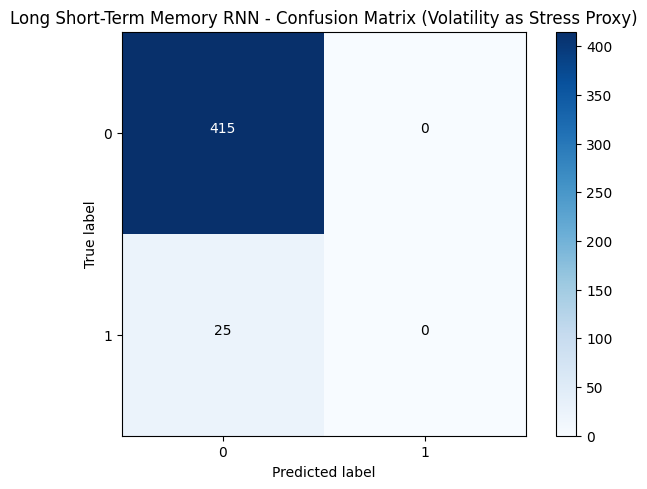

In [ ]:
plot_confusion_matrix(cm=lstm_cm_bench_2, classes=[0,1], normalize= False,  title='Long Short-Term Memory RNN - Confusion Matrix (Volatility as Stress Proxy)')

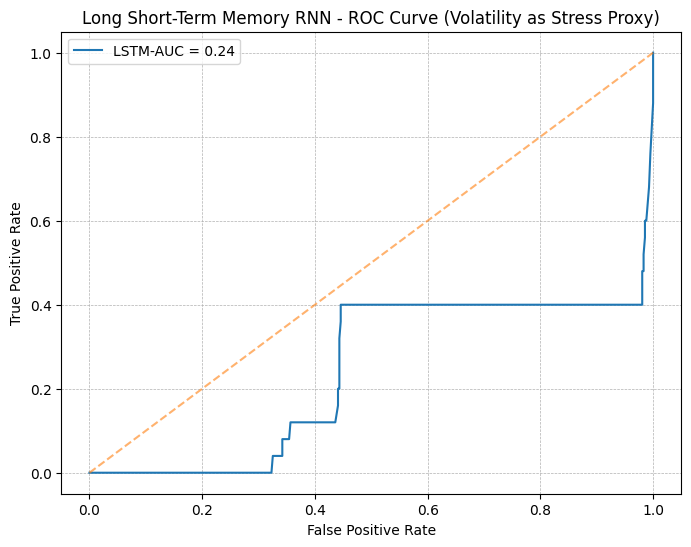

In [ ]:
fpr, tpr, thr = roc_curve(y_test_seq_bench_2, lstm_probs_bench_2)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LSTM-AUC = {lstm_roc_auc_bench_2:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Long Short-Term Memory RNN - ROC Curve (Volatility as Stress Proxy)")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [ ]:
lstm_results_bench_2 = pd.DataFrame({'Recall': lstm_recall_bench_2, 'F1-Score': lstm_f1_bench_2, 'ROC-AUC': lstm_roc_auc_bench_2},index=['Long Short-Term Memory RNN (Volatility as Stress Proxy)'])
ml_results_bench_2 = pd.concat([lr_results_2.round(2), svm_results_2.round(2), lstm_results_bench_2.round(2)])
ml_results_bench_2

,Recall,F1-Score,ROC-AUC
Logistic Regression (Volatility as Stress Proxy),0.0,0.00,0.50
Support Vector Machines (Volatility as Stress Proxy),0.4,0.15,0.59
Long Short-Term Memory RNN (Volatility as Stress Proxy),0.0,0.00,0.24


```python
ml_results_bench_2.to_csv("ml_results_bench_2.csv", index=True)
files.download("ml_results_bench_2.csv")
ml_results_bench_2.to_parquet("ml_results_bench_2.parquet", index=True)
files.download("ml_results_bench_2.parquet")
```